# 03 — Limpeza do IBGE (Censo 2022, agregados por municípios)

**Projeto Aplicado II — Guilherme Cunha Oliveira (RA 10754621) e Gabriel Lucca Simionato (RA 10751300)**

Notebook nas 10 seções do *Plano de Limpeza das Bases*. Entrada preservada em `db/bases_brutas/ibge/`; saída em `db/bases_tratadas/ibge/`.

## 1. Objetivo

Produzir a fonte de **contexto populacional e domiciliar** do projeto: uma única linha por município, com código compatível com `ID_MN_RESI` do SINAN, população (denominador dos indicadores relativos), área e densidade, domicílios ocupados e média de moradores, e — quando aprovados pelo dicionário oficial — os indicadores de abastecimento de água, esgotamento sanitário e coleta de lixo previstos na seção 5 do plano. As medidas conservam a referência de 2022 e descrevem o município, não o domicílio individual.

In [1]:
# ============================================================
# 1. OBJETIVO
# ============================================================
ENTRADAS_PREVISTAS = ["Agregados_por_municipios_basico_BR.csv", "Agregados_por_municipios_caracteristicas_domicilio1_BR.csv",
                      "Agregados_por_municipios_caracteristicas_domicilio2_BR.csv", "Agregados_por_municipios_caracteristicas_domicilio3_BR.csv"]
SAIDA_PREVISTA = "db/bases_tratadas/ibge/ibge_municipio_2022_tratado.csv"

## 2. Bibliotecas

Além de pandas e NumPy, `openpyxl` fica disponível para ler o dicionário XLSX quando ele for colocado em `db/bases_brutas/ibge/dicionario/`.

In [2]:
# ============================================================
# 2. BIBLIOTECAS
# ============================================================
import json, hashlib, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import openpyxl; OPENPYXL = openpyxl.__version__
except ImportError:
    OPENPYXL = None
warnings.filterwarnings("ignore"); plt.rcParams.update({"axes.grid": True, "grid.alpha": .3})
pd.set_option("display.width", 160, "display.max_columns", 40)
print("pandas", pd.__version__, "| numpy", np.__version__, "| openpyxl", OPENPYXL)

pandas 3.0.2 | numpy 2.4.4 | openpyxl 3.1.5


## 3. Caminhos

In [3]:
# ============================================================
# 3. CAMINHOS
# ============================================================
RAIZ = Path("..").resolve()
BRUTA, TRATADA = RAIZ/"db/bases_brutas/ibge", RAIZ/"db/bases_tratadas/ibge"
TRATADA.mkdir(parents=True, exist_ok=True)
ARQ = {"basico": BRUTA/ENTRADAS_PREVISTAS[0], "domicilio1": BRUTA/ENTRADAS_PREVISTAS[1], "domicilio2": BRUTA/ENTRADAS_PREVISTAS[2], "domicilio3": BRUTA/ENTRADAS_PREVISTAS[3]}
ARQ_MAPEAMENTO = BRUTA/"dicionario/mapeamento_indicadores.csv"
ARQ_TRATADO    = TRATADA/"ibge_municipio_2022_tratado.csv"
ARQ_LOG        = TRATADA/"ibge_limpeza_log.json"
SINAN_TRATADO  = RAIZ/"db/bases_tratadas/sinan/sinan_dengue_2025_tratado.parquet"   # só para validar a chave
LOG = {"entradas": [str(p.relative_to(RAIZ)) for p in ARQ.values()], "saida": str(ARQ_TRATADO.relative_to(RAIZ)), "etapas": {}}
for k, p in ARQ.items(): print(f"{k:11s} existe: {p.exists()}")
print("mapeamento do dicionário existe:", ARQ_MAPEAMENTO.exists())

basico      existe: True
domicilio1  existe: True
domicilio2  existe: True
domicilio3  existe: True
mapeamento do dicionário existe: True


## 4. Carregamento

Os quatro arquivos usam `;`, codificação latin-1 e vírgula decimal. Lemos tudo como texto e registramos a identidade de cada arquivo.

In [4]:
# ============================================================
# 4. CARREGAMENTO
# ============================================================
def sha256(p):
    h = hashlib.sha256()
    with open(p, "rb") as f:
        for parte in iter(lambda: f.read(1 << 24), b""): h.update(parte)
    return h.hexdigest()
ibge = {k: pd.read_csv(p, sep=";", encoding="latin1", dtype=str) for k, p in ARQ.items()}
LOG["etapas"]["identidade"] = {k: {"tamanho_MB": round(p.stat().st_size/1e6, 1), "sha256": sha256(p), "shape": list(ibge[k].shape)} for k, p in ARQ.items()}
for k, d in ibge.items(): print(f"{k:11s} {d.shape} | colunas {d.columns[0]} … {d.columns[-1]}")
ibge["basico"].head(3).T

basico      (5570, 26) | colunas CD_MUN … v0009
domicilio1  (5570, 91) | colunas CD_MUN … V00089
domicilio2  (5570, 408) | colunas CD_MUN … V00495
domicilio3  (5570, 150) | colunas CD_MUN … V00643


,0,1,2
CD_MUN,1100015,1100023,1100031
NM_MUN,Alta Floresta D'Oeste,Ariquemes,Cabixi
CD_REGIAO,1,1,1
NM_REGIAO,Norte,Norte,Norte
CD_UF,11,11,11
NM_UF,Rondônia,Rondônia,Rondônia
CD_NU,1100015001,.,.
NM_NU,Loteamento Canaã,NaN,NaN
CD_AGLOM,.,110002300015,110003100004
NM_AGLOM,NaN,Vila Rica,Agrovila do PA Estrela do Oeste


## 5. Diagnóstico inicial

Unicidade e formato de `CD_MUN`, nulos e marcadores especiais (o IBGE usa `.` ou `X` para valores não disponíveis ou omitidos), consistência das variáveis do arquivo básico e validação contra um município conhecido.

In [5]:
# ============================================================
# 5. DIAGNÓSTICO INICIAL
# ============================================================
for k, d in ibge.items():
    cols_num = [c for c in d.columns if c.lower().startswith("v") or c == "AREA_KM2"]      # variáveis numéricas; nomes e códigos de recorte ficam de fora
    vals = d[cols_num].values.ravel()
    especiais = pd.Series(vals[~pd.Series(vals).str.fullmatch(r"-?\d+([,.]\d+)?").fillna(False).values]).value_counts().head(5).to_dict()
    print(f"{k:11s} CD_MUN único: {d.CD_MUN.is_unique} | dígitos: {d.CD_MUN.str.len().unique()} | variáveis numéricas: {len(cols_num)} | nulos nelas: {int(d[cols_num].isna().sum().sum())} | marcadores não numéricos: {especiais or 'nenhum'}")
b = ibge["basico"]
recortes = ["CD_NU","NM_NU","CD_AGLOM","NM_AGLOM","CD_RGINT","NM_RGINT","CD_RGI","NM_RGI","CD_CONCURB","NM_CONCURB"]
print("\nbásico — recortes territoriais (não usados): campos com '.' ou vazio =", {c: int(((b[c] == ".") | b[c].isna()).sum()) for c in recortes})

basico      CD_MUN único: True | dígitos: [7] | variáveis numéricas: 10 | nulos nelas: 0 | marcadores não numéricos: nenhum
domicilio1  CD_MUN único: True | dígitos: [7] | variáveis numéricas: 89 | nulos nelas: 0 | marcadores não numéricos: nenhum


domicilio2  CD_MUN único: True | dígitos: [7] | variáveis numéricas: 406 | nulos nelas: 0 | marcadores não numéricos: nenhum
domicilio3  CD_MUN único: True | dígitos: [7] | variáveis numéricas: 148 | nulos nelas: 0 | marcadores não numéricos: nenhum

básico — recortes territoriais (não usados): campos com '.' ou vazio = {'CD_NU': 3712, 'NM_NU': 3712, 'CD_AGLOM': 3251, 'NM_AGLOM': 3251, 'CD_RGINT': 0, 'NM_RGINT': 0, 'CD_RGI': 0, 'NM_RGI': 0, 'CD_CONCURB': 4910, 'NM_CONCURB': 4910}


In [6]:
b = ibge["basico"]
num_b = b[["AREA_KM2","v0001","v0002","v0003","v0004","v0005","v0006","v0007","v0008","v0009"]].apply(lambda s: pd.to_numeric(s.str.replace(",", "."), errors="coerce"))
print(num_b.describe().round(2).T.to_string())
sp = b[b.CD_MUN == "3550308"].iloc[0]
print("\nValidação — São Paulo:", {c: sp[c] for c in ["NM_MUN","NM_UF","NM_REGIAO","AREA_KM2","v0001","v0005","v0007"]})
print("soma de v0001 (população residente, Brasil):", f"{int(num_b.v0001.sum()):,}")
print("municípios com AREA_KM2 nula ou zero:", int((num_b.AREA_KM2.isna() | (num_b.AREA_KM2 <= 0)).sum()))
print("\nRegiões:", b.NM_REGIAO.value_counts().to_dict())

           count      mean        std     min      25%       50%       75%          max
AREA_KM2  5570.0   1525.55    5605.45    3.57   204.76    417.69   1026.61    159533.31
v0001     5570.0  36459.74  206518.73  833.00  5228.00  11065.00  24427.25  11451999.00
v0002     5570.0  16284.49   91369.04  414.00  2534.25   5043.00  11027.75   4996529.00
v0003     5570.0  16265.72   91297.41  413.00  2532.25   5031.00  11007.25   4992162.00
v0004     5570.0     18.76      79.76    0.00     2.00      5.00     14.00      4367.00
v0005     5570.0      2.84       0.32    2.30     2.70      2.80      2.90         5.80
v0006     5570.0      0.02       0.02    0.00     0.00      0.01      0.03         0.39
v0007     5570.0  13020.17   77653.89  322.00  1876.25   3889.00   8386.25   4316336.00
v0008     5570.0   1198.74    3657.83    2.00   222.00    449.50    981.75    107402.00
v0009     5570.0   2046.81   11371.95    7.00   320.25    649.00   1437.75    589020.00

Validação — São Paulo: {'NM_MUN

Leitura do diagnóstico: 5.570 municípios em cada arquivo, `CD_MUN` único com 7 dígitos, sem nulos nem marcadores de omissão nas variáveis numéricas (os `.` do arquivo básico estão apenas nos códigos de aglomeração e concentração urbana, vazios para municípios fora desses recortes, que não são usados). No arquivo básico, `v0001` (população residente) soma 203,1 milhões e São Paulo aparece com 11.451.999 habitantes, 4.316.336 domicílios particulares permanentes ocupados (`v0007`) e 2,6 moradores por domicílio (`v0005`) — valores coerentes com a divulgação do Censo 2022, o que confirma o papel dessas três variáveis. As demais variáveis do básico (`v0002` a `v0004`, `v0006`, `v0008`, `v0009`) e as 643 dos arquivos de domicílio só entram após confirmação no dicionário.

## 6. Regras de limpeza

- **R1 — Chave.** `cod_municipio` = 6 primeiros dígitos de `CD_MUN` (o sétimo é dígito verificador, ausente no SINAN e no CNES); `CD_MUN` completo é mantido como `cd_mun_ibge7`.
- **R2 — Variáveis do básico.** Entram `v0001` → `populacao`, `AREA_KM2` → `area_km2`, `v0007` → `domicilios_ocupados`, `v0005` → `media_moradores`, mais nome, UF e região. Deriva-se `densidade_hab_km2 = populacao / area_km2`. Vírgula decimal convertida para ponto.
- **R3 — Indicadores domiciliares.** Calculados **somente** a partir das linhas com `aprovado = sim` em `dicionario/mapeamento_indicadores.csv`, que traz numerador e denominador conferidos no dicionário oficial. O notebook verifica que os códigos existem no arquivo indicado e que o denominador é positivo; nenhuma variável é escolhida pelo nome do arquivo. Enquanto o mapeamento não estiver aprovado, a saída não tem `pct_agua`, `pct_esgoto` e `pct_coleta_lixo`.
- **R4 — Uma linha por município.** A saída é validada como única em `cod_municipio` antes da integração.
- **R5 — Compatibilidade com o SINAN.** Os códigos de município de residência da base tratada do SINAN são conferidos contra a saída: casos sem correspondência são contados e os códigos listados.

In [7]:
# ============================================================
# 6. REGRAS DE LIMPEZA
# ============================================================
VARS_BASICO = {"v0001": "populacao", "AREA_KM2": "area_km2", "v0007": "domicilios_ocupados", "v0005": "media_moradores"}
mapeamento = pd.read_csv(ARQ_MAPEAMENTO, dtype=str) if ARQ_MAPEAMENTO.exists() else pd.DataFrame(columns=["indicador","arquivo","numerador","denominador","descricao","aprovado"])
aprovados = mapeamento[mapeamento.aprovado.str.lower() == "sim"].copy()
print("linhas no mapeamento:", len(mapeamento), "| aprovadas:", len(aprovados))
mapeamento

linhas no mapeamento: 3 | aprovadas: 0


,indicador,arquivo,numerador,denominador,descricao,aprovado
0,pct_agua_rede,domicilio2,V00xxx,V00xxx,DPPO com abastecimento de água pela rede geral...,nao
1,pct_esgoto_rede,domicilio2,V00xxx,V00xxx,DPPO com esgotamento por rede geral ou pluvial...,nao
2,pct_coleta_lixo,domicilio2,V00xxx,V00xxx,DPPO com lixo coletado (direto ou caçamba) / t...,nao


## 7. Aplicação

In [8]:
# ============================================================
# 7. APLICAÇÃO
# ============================================================
def numero(s): return pd.to_numeric(s.str.replace(",", ".", regex=False), errors="coerce")
b = ibge["basico"]
saida = pd.DataFrame({"cod_municipio": b.CD_MUN.str[:6], "cd_mun_ibge7": b.CD_MUN, "nome_municipio": b.NM_MUN, "uf": b.NM_UF, "regiao": b.NM_REGIAO})
for v, nome in VARS_BASICO.items(): saida[nome] = numero(b[v])                          # R2
saida["densidade_hab_km2"] = (saida.populacao / saida.area_km2).round(2)

indicadores_calculados, problemas = [], []                                                  # R3
for _, r in aprovados.iterrows():
    d = ibge.get(r.arquivo)
    if d is None or r.numerador not in d.columns or r.denominador not in d.columns:
        problemas.append(f"{r.indicador}: arquivo/códigos não encontrados ({r.arquivo}, {r.numerador}, {r.denominador})"); continue
    num, den = numero(d[r.numerador]), numero(d[r.denominador])
    if (den <= 0).any() or den.isna().any(): problemas.append(f"{r.indicador}: denominador nulo ou zero em {int(((den <= 0) | den.isna()).sum())} municípios")
    s = pd.DataFrame({"cod_municipio": d.CD_MUN.str[:6], r.indicador: (num / den * 100).round(2)})
    saida = saida.merge(s, on="cod_municipio", how="left"); indicadores_calculados.append(r.indicador)
print("indicadores domiciliares calculados:", indicadores_calculados or "nenhum (mapeamento do dicionário ainda não aprovado)")
if problemas: print("problemas:", *problemas, sep="\n  ")
LOG["etapas"]["aplicacao"] = {"variaveis_basico": VARS_BASICO, "indicadores_domiciliares": indicadores_calculados, "problemas": problemas}
saida.head()

indicadores domiciliares calculados: nenhum (mapeamento do dicionário ainda não aprovado)


,cod_municipio,cd_mun_ibge7,nome_municipio,uf,regiao,populacao,area_km2,domicilios_ocupados,media_moradores,densidade_hab_km2
0,110001,1100015,Alta Floresta D'Oeste,Rondônia,Norte,21494,7067.126782,7699,2.8,3.04
1,110002,1100023,Ariquemes,Rondônia,Norte,96833,4426.143126,34784,2.8,21.88
2,110003,1100031,Cabixi,Rondônia,Norte,5351,1314.351845,1967,2.7,4.07
3,110004,1100049,Cacoal,Rondônia,Norte,86887,3792.999707,31931,2.7,22.91
4,110005,1100056,Cerejeiras,Rondônia,Norte,15890,2783.297041,5876,2.7,5.71


## 8. Validação

Unicidade por município, ausência de nulos nas variáveis do básico, densidade plausível, cobertura das cinco regiões e compatibilidade da chave com a base tratada do SINAN (R5).

In [9]:
# ============================================================
# 8. VALIDAÇÃO
# ============================================================
checks = {
 "uma linha por cod_municipio": bool(saida.cod_municipio.is_unique),
 "5570 municipios": bool(len(saida) == 5570),
 "cod_municipio 6 digitos": bool(saida.cod_municipio.str.len().eq(6).all()),
 "sem nulos em populacao/area/domicilios/media": bool(saida[list(VARS_BASICO.values())].notna().all().all()),
 "populacao > 0": bool((saida.populacao > 0).all()),
 "densidade finita": bool(np.isfinite(saida.densidade_hab_km2).all()),
}
print(pd.Series(checks).to_string()); assert all(checks.values()); LOG["etapas"]["validacao"] = checks
print(saida[["populacao","area_km2","domicilios_ocupados","media_moradores","densidade_hab_km2"]].describe().round(1).T.to_string())

uma linha por cod_municipio                     True
5570 municipios                                 True
cod_municipio 6 digitos                         True
sem nulos em populacao/area/domicilios/media    True
populacao > 0                                   True
densidade finita                                True
                      count     mean       std    min     25%      50%      75%         max
populacao            5570.0  36459.7  206518.7  833.0  5228.0  11065.0  24427.2  11451999.0
area_km2             5570.0   1525.6    5605.4    3.6   204.8    417.7   1026.6    159533.3
domicilios_ocupados  5570.0  13020.2   77653.9  322.0  1876.2   3889.0   8386.2   4316336.0
media_moradores      5570.0      2.8       0.3    2.3     2.7      2.8      2.9         5.8
densidade_hab_km2    5570.0    116.0     595.0    0.2    11.3     24.3     53.6     13417.0


In [10]:
# R5 — compatibilidade com a chave do SINAN tratado
if SINAN_TRATADO.exists():
    chaves_sinan = pd.read_parquet(SINAN_TRATADO, columns=["cod_municipio"]).cod_municipio
    presentes = chaves_sinan.isin(saida.cod_municipio)
    sem = chaves_sinan[~presentes & chaves_sinan.notna()].astype(str).value_counts()
    compat = {"casos_sinan": int(len(chaves_sinan)), "casos_com_municipio_no_ibge": int(presentes.sum()), "casos_sem_correspondencia": int((~presentes).sum()),
              "casos_com_codigo_nulo": int(chaves_sinan.isna().sum()), "codigos_sem_correspondencia": sem.to_dict(),
              "municipios_do_sinan_cobertos": int(chaves_sinan.dropna().nunique() - len(sem)), "municipios_do_sinan": int(chaves_sinan.dropna().nunique())}
    print(json.dumps(compat, indent=2)); LOG["etapas"]["compatibilidade_sinan"] = compat
else:
    print("base tratada do SINAN não encontrada — execute 01_limpeza_sinan.ipynb antes para validar a chave")

{
  "casos_sinan": 1481802,
  "casos_com_municipio_no_ibge": 1481793,
  "casos_sem_correspondencia": 9,
  "casos_com_codigo_nulo": 5,
  "codigos_sem_correspondencia": {
    "530160": 1,
    "510183": 1,
    "410000": 1,
    "350000": 1
  },
  "municipios_do_sinan_cobertos": 4826,
  "municipios_do_sinan": 4830
}


Os códigos do SINAN sem correspondência são do tipo `UU0000` (município de residência ignorado dentro da UF) ou inexistentes no Censo 2022; são poucos casos e ficarão com contexto nulo na integração, preservados.

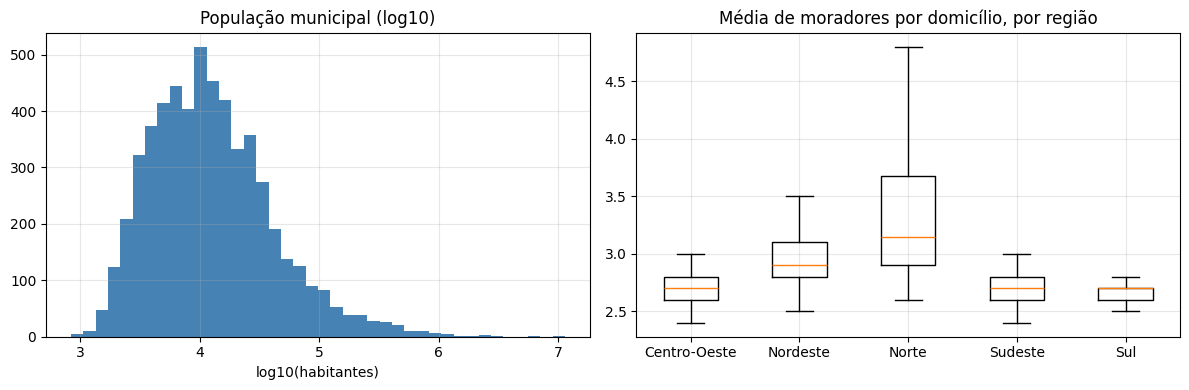

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.log10(saida.populacao), bins=40, color="steelblue"); ax[0].set_title("População municipal (log10)"); ax[0].set_xlabel("log10(habitantes)")
regs = sorted(saida.regiao.unique()); ax[1].boxplot([saida.loc[saida.regiao == r, "media_moradores"] for r in regs], tick_labels=regs, showfliers=False); ax[1].set_title("Média de moradores por domicílio, por região")
plt.tight_layout(); plt.show()

## 9. Exportação

In [12]:
# ============================================================
# 9. EXPORTAÇÃO
# ============================================================
saida.to_csv(ARQ_TRATADO, index=False)
LOG["etapas"]["exportacao"] = {"linhas": int(len(saida)), "colunas": list(saida.columns), "tamanho_KB": round(ARQ_TRATADO.stat().st_size/1e3)}
LOG["executado_em"] = pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")
ARQ_LOG.write_text(json.dumps(LOG, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
print(json.dumps(LOG["etapas"]["exportacao"], indent=2, ensure_ascii=False))

{
  "linhas": 5570,
  "colunas": [
    "cod_municipio",
    "cd_mun_ibge7",
    "nome_municipio",
    "uf",
    "regiao",
    "populacao",
    "area_km2",
    "domicilios_ocupados",
    "media_moradores",
    "densidade_hab_km2"
  ],
  "tamanho_KB": 444
}


## 10. Resumo

In [13]:
# ============================================================
# 10. RESUMO
# ============================================================
pd.DataFrame([
    ["arquivos de entrada", 4, "básico + domicílios 1, 2, 3"],
    ["municípios (linhas) em cada entrada", 5570, "CD_MUN único, 7 dígitos"],
    ["variáveis disponíveis nos arquivos de domicílio", 643, "V00001–V00643, codificadas"],
    ["variáveis do básico usadas", len(VARS_BASICO), ", ".join(VARS_BASICO)],
    ["indicadores domiciliares calculados", len(indicadores_calculados), "dependem do mapeamento aprovado"],
    ["linhas na saída", len(saida), "uma por município"],
    ["colunas na saída", saida.shape[1], ""],
    ["casos do SINAN com município no IBGE", LOG["etapas"].get("compatibilidade_sinan", {}).get("casos_com_municipio_no_ibge", "n/d"), "R5"],
], columns=["item","valor","observação"])

,item,valor,observação
0,arquivos de entrada,4,"básico + domicílios 1, 2, 3"
1,municípios (linhas) em cada entrada,5570,"CD_MUN único, 7 dígitos"
2,variáveis disponíveis nos arquivos de domicílio,643,"V00001–V00643, codificadas"
3,variáveis do básico usadas,4,"v0001, AREA_KM2, v0007, v0005"
4,indicadores domiciliares calculados,0,dependem do mapeamento aprovado
5,linhas na saída,5570,uma por município
6,colunas na saída,10,
7,casos do SINAN com município no IBGE,1481793,R5
